# Renúncias fiscais sobre empresas sediadas em Santos (SP)

Este notebook organiza a leitura do CSV do Portal da Transpar?ncia e resume a base de benefici?rios de ren?ncias fiscais no recorte do munic?pio de Santos.

O foco aqui ? descrever a distribui??o dos valores, identificar os setores mais presentes e observar quais tipos de benef?cio concentram a maior parte do total. A proposta ? reprodutibilidade, n?o uma conclus?o autom?tica sobre arrecada??o municipal.


## 1. Premissa importante

Esta base n?o mede diretamente perda de arrecada??o da Prefeitura de Santos.

O que ela mostra s?o ren?ncias incidentes sobre empresas localizadas no munic?pio, com predomin?ncia de tributos federais, como COFINS, PIS, IPI e Imposto de Importa??o.

A pergunta mais adequada para este arquivo ?: quais empresas, setores e mecanismos concentram os maiores valores de ren?ncia no recorte de Santos?


## 1.1. Ambiente

Antes de executar o notebook, instale as depend?ncias com `pip install -r requirements.txt`. Isso evita deixar comandos de instala??o soltos no meio da an?lise.


Os blocos abaixo partem do pressuposto de que `pandas`, `numpy` e `matplotlib` j? est?o dispon?veis no ambiente do projeto.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [4]:
# Leitura do CSV em ambientes locais ou hospedados
possible_files = [
    Path('dados/beneficiario.csv'),
    Path('dados/beneficiario (1).csv'),
    Path('beneficiario.csv'),
    Path('beneficiario (1).csv'),
    Path('/content/beneficiario.csv'),
    Path('/content/beneficiario (1).csv'),
    Path('/mnt/data/beneficiario.csv'),
    Path('/mnt/data/beneficiario (1).csv'),
]

csv_path = next((file_path for file_path in possible_files if file_path.exists()), None)
if csv_path is None:
    searched = '\n'.join(f'- {file_path}' for file_path in possible_files)
    raise FileNotFoundError(
        'Arquivo CSV n?o encontrado. Salve `beneficiario.csv` na raiz do projeto ou na pasta `dados/`.\n'
        f'Locais verificados:\n{searched}'
    )

raw = pd.read_csv(csv_path, sep=';')
raw.head()


,CNPJ,Beneficiário,Nome Fantasia,UF,Município,CNAE,Benefício Fiscal,Valor Renunciado(R$),Unnamed: 8
0,04.571.158/0001-72,SETE MARES LOCADORA DE VEICULOS LTDA,NaN,SÃO PAULO,SANTOS,49299 - Transporte rodoviário coletivo de pass...,Programa Emergencial de Retomada do Setor de E...,"8,64",NaN
1,33.161.980/0001-63,BEDSON - COMERCIO DE PRODUTOS ANIMAIS LTDA,BEDSON BRASIL,SÃO PAULO,SANTOS,46443 - Comércio atacadista de produtos farmac...,PIS,"14,00",NaN
2,04.571.158/0001-72,SETE MARES LOCADORA DE VEICULOS LTDA,NaN,SÃO PAULO,SANTOS,49299 - Transporte rodoviário coletivo de pass...,Programa Emergencial de Retomada do Setor de E...,"19,20",NaN
3,04.879.841/0003-33,ADISSEO BRASIL NUTRICAO ANIMAL LTDA,NaN,SÃO PAULO,SANTOS,46397 - Comércio atacadista de produtos alimen...,Imposto de Importação,"26,00",NaN
4,02.176.957/0001-19,HANJIN SHIPPING DO BRASIL LTDA - EM LIQUIDACAO,NaN,SÃO PAULO,SANTOS,52320 - Atividades de agenciamento marítimo,PIS,"28,00",NaN


## 2. Limpeza e preparação

In [5]:

df = raw.copy()

# Remove coluna vazia, se existir
if 'Unnamed: 8' in df.columns:
    df = df.drop(columns=['Unnamed: 8'])

# Padronização básica de texto
for col in ['CNPJ', 'Beneficiário', 'Nome Fantasia', 'UF', 'Município', 'CNAE', 'Benefício Fiscal']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Conversão monetária (formato brasileiro -> float)
df['valor_renunciado'] = (
    df['Valor Renunciado(R$)']
      .astype(str)
      .str.replace('.', '', regex=False)
      .str.replace(',', '.', regex=False)
      .pipe(pd.to_numeric, errors='coerce')
)

# Foco apenas em Santos
santos = df[df['Município'].eq('SANTOS')].copy()

santos.head()


,CNPJ,Beneficiário,Nome Fantasia,UF,Município,CNAE,Benefício Fiscal,Valor Renunciado(R$),valor_renunciado
0,04.571.158/0001-72,SETE MARES LOCADORA DE VEICULOS LTDA,nan,SÃO PAULO,SANTOS,49299 - Transporte rodoviário coletivo de pass...,Programa Emergencial de Retomada do Setor de E...,"8,64",8.64
1,33.161.980/0001-63,BEDSON - COMERCIO DE PRODUTOS ANIMAIS LTDA,BEDSON BRASIL,SÃO PAULO,SANTOS,46443 - Comércio atacadista de produtos farmac...,PIS,"14,00",14.00
2,04.571.158/0001-72,SETE MARES LOCADORA DE VEICULOS LTDA,nan,SÃO PAULO,SANTOS,49299 - Transporte rodoviário coletivo de pass...,Programa Emergencial de Retomada do Setor de E...,"19,20",19.20
3,04.879.841/0003-33,ADISSEO BRASIL NUTRICAO ANIMAL LTDA,nan,SÃO PAULO,SANTOS,46397 - Comércio atacadista de produtos alimen...,Imposto de Importação,"26,00",26.00
4,02.176.957/0001-19,HANJIN SHIPPING DO BRASIL LTDA - EM LIQUIDACAO,nan,SÃO PAULO,SANTOS,52320 - Atividades de agenciamento marítimo,PIS,"28,00",28.00


In [6]:

# Checagem rápida da base
resumo_base = pd.DataFrame({
    'Métrica': [
        'Registros analisados',
        'Empresas únicas',
        'CNPJs únicos',
        'Setores CNAE',
        'Tipos de benefício fiscal',
        'Valor total renunciado (R$)',
        'Média por registro (R$)',
        'Mediana por registro (R$)',
        'Menor valor (R$)',
        'Maior valor (R$)'
    ],
    'Valor': [
        len(santos),
        santos['Beneficiário'].nunique(),
        santos['CNPJ'].nunique(),
        santos['CNAE'].nunique(),
        santos['Benefício Fiscal'].nunique(),
        santos['valor_renunciado'].sum(),
        santos['valor_renunciado'].mean(),
        santos['valor_renunciado'].median(),
        santos['valor_renunciado'].min(),
        santos['valor_renunciado'].max(),
    ]
})
resumo_base


,Métrica,Valor
0,Registros analisados,8.370000e+02
1,Empresas únicas,3.080000e+02
2,CNPJs únicos,3.250000e+02
3,Setores CNAE,1.070000e+02
4,Tipos de benefício fiscal,1.900000e+01
5,Valor total renunciado (R$),5.897833e+09
6,Média por registro (R$),7.046396e+06
7,Mediana por registro (R$),5.612900e+04
8,Menor valor (R$),8.640000e+00
9,Maior valor (R$),1.045963e+09


### Leitura inicial

Logo na inspe??o descritiva, a diferen?a entre m?dia e mediana j? aponta uma base muito concentrada. Isso costuma acontecer quando poucos registros puxam o total para cima, enquanto a maioria permanece em valores bem menores.

Por esse motivo, o ranking e a curva acumulada s?o mais informativos do que o total isolado.


## 3. Ranking das empresas com maiores renúncias

In [7]:

top_empresas = (
    santos.groupby('Beneficiário', as_index=False)['valor_renunciado']
          .sum()
          .sort_values('valor_renunciado', ascending=False)
)

total = santos['valor_renunciado'].sum()
top_empresas['participacao_%'] = 100 * top_empresas['valor_renunciado'] / total

top_empresas.head(10)


,Beneficiário,valor_renunciado,participacao_%
19,ALFA LULA ALTO OPERACOES MARITIMAS LTDA,2.005278e+09,34.000243
103,EQUINOR BRASIL ENERGIA LTDA.,7.408672e+08,12.561685
212,PETROLEO BRASILEIRO S A PETROBRAS,4.921260e+08,8.344183
50,BUNGE ALIMENTOS S/A,3.969642e+08,6.730679
287,TRSP - TERMINAL DE REGASEIFICACAO DE GNL DE SA...,3.405098e+08,5.773472
190,MOINHO PAULISTA SA,2.839661e+08,4.814754
300,VOPAK BRASIL S.A.,2.223363e+08,3.769796
154,KAROON PETROLEO & GAS LTDA,1.593707e+08,2.702191
253,SAT SISTEMA A TRIBUNA DE COMUNICACAO-SANTOS LTDA,1.519344e+08,2.576106
14,AGEO TERMINAIS E ARMAZENS GERAIS S.A,1.265316e+08,2.145391


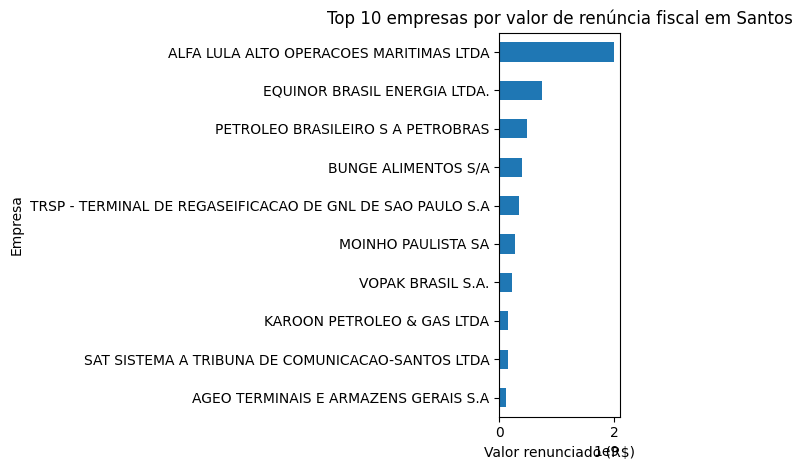

In [9]:
import matplotlib.pyplot as plt

ax = top_empresas.head(10).sort_values('valor_renunciado').plot(
    kind='barh', x='Beneficiário', y='valor_renunciado', legend=False
)
ax.set_title('Top 10 empresas por valor de renúncia fiscal em Santos')
ax.set_xlabel('Valor renunciado (R$)')
ax.set_ylabel('Empresa')
plt.tight_layout()
plt.show()


### Leitura do ranking

Os primeiros lugares n?o aparecem espalhados por atividades aleat?rias. O que surge com mais for?a s?o cadeias j? muito presentes em Santos, como petr?leo e g?s, opera??es portu?rias, armazenagem, log?stica e ind?stria aliment?cia.

A leitura mais segura ? que a base acompanha a estrutura econ?mica local.


## 4. Concentração da renúncia fiscal

In [10]:

concentracao = []
for n in [1, 5, 10, 20]:
    valor = top_empresas.head(n)['valor_renunciado'].sum()
    concentracao.append({
        'Grupo': f'Top {n}',
        'Valor acumulado (R$)': valor,
        'Participação (%)': 100 * valor / total
    })

concentracao_df = pd.DataFrame(concentracao)
concentracao_df


,Grupo,Valor acumulado (R$),Participação (%)
0,Top 1,2.005278e+09,34.000243
1,Top 5,3.975745e+09,67.410262
2,Top 10,4.919884e+09,83.418500
3,Top 20,5.504249e+09,93.326625


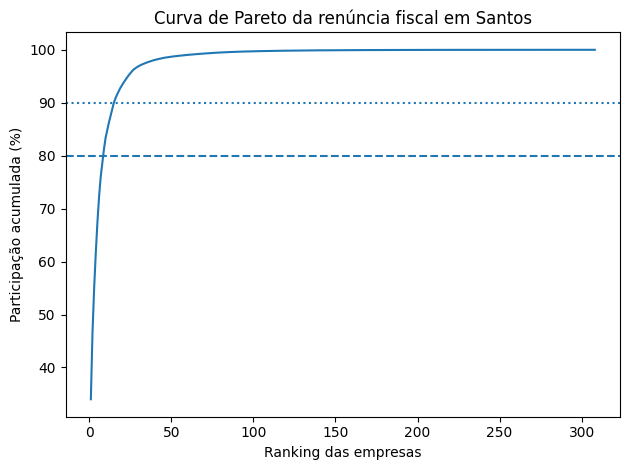

In [11]:

pareto = top_empresas.copy().reset_index(drop=True)
pareto['empresa_rank'] = pareto.index + 1
pareto['participacao_acumulada_%'] = 100 * pareto['valor_renunciado'].cumsum() / total

plt.plot(pareto['empresa_rank'], pareto['participacao_acumulada_%'])
plt.axhline(80, linestyle='--')
plt.axhline(90, linestyle=':')
plt.title('Curva de Pareto da renúncia fiscal em Santos')
plt.xlabel('Ranking das empresas')
plt.ylabel('Participação acumulada (%)')
plt.tight_layout()
plt.show()


### Leitura da concentra??o

A concentra??o ? elevada: poucos registros respondem por parcela muito grande do valor total. Em termos de debate p?blico, isso importa mais do que o montante agregado sozinho, porque mostra quem est? no centro da pol?tica de benef?cios.


## 5. Análise por setor econômico (CNAE)

In [12]:

top_cnae = (
    santos.groupby('CNAE', as_index=False)['valor_renunciado']
          .sum()
          .sort_values('valor_renunciado', ascending=False)
)

top_cnae['participacao_%'] = 100 * top_cnae['valor_renunciado'] / total

top_cnae.head(10)


,CNAE,valor_renunciado,participacao_%
2,09106 - Atividades de apoio à extração de petr...,2.006724e+09,34.024771
1,06000 - Extração de petróleo e gás natural,1.351300e+09,22.911808
5,10627 - Moagem de trigo e fabricação de derivados,7.462112e+08,12.652295
55,52117 - Armazenamento,4.089362e+08,6.933668
0,00000 - Sem informação,3.526726e+08,5.979698
31,46842 - Comércio atacadista de produtos químic...,2.236472e+08,3.792023
68,60217 - Atividades de televisão aberta,1.591247e+08,2.698020
57,52311 - Gestão de portos e terminais,1.573942e+08,2.668678
20,46397 - Comércio atacadista de produtos alimen...,8.421875e+07,1.427961
3,10201 - Preservação do pescado e fabricação de...,7.360916e+07,1.248071


/tmp/ipykernel_1081/567441091.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


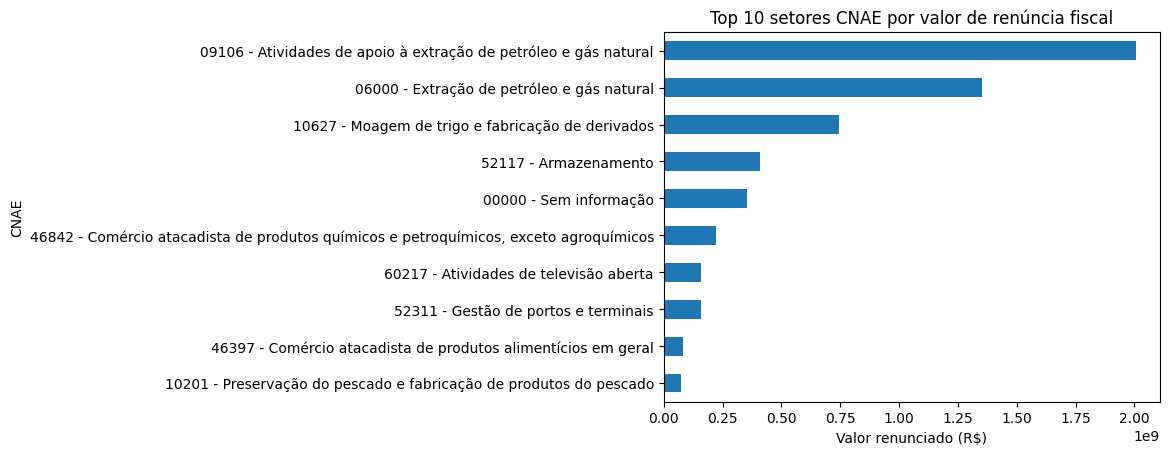

In [13]:

ax = top_cnae.head(10).sort_values('valor_renunciado').plot(
    kind='barh', x='CNAE', y='valor_renunciado', legend=False
)
ax.set_title('Top 10 setores CNAE por valor de renúncia fiscal')
ax.set_xlabel('Valor renunciado (R$)')
ax.set_ylabel('CNAE')
plt.tight_layout()
plt.show()


### Leitura setorial

Os setores com maior peso se relacionam diretamente com a economia portu?ria e industrial do munic?pio. Petr?leo, apoio operacional, armazenagem, terminais, com?rcio exterior e alimentos aparecem de forma recorrente.

Isso n?o prova efici?ncia do incentivo, mas ajuda a situar onde ele se concentra.


## 6. Análise por tipo de benefício fiscal

In [14]:

top_beneficios = (
    santos.groupby('Benefício Fiscal', as_index=False)['valor_renunciado']
          .sum()
          .sort_values('valor_renunciado', ascending=False)
)

top_beneficios['participacao_%'] = 100 * top_beneficios['valor_renunciado'] / total

top_beneficios.head(10)


,Benefício Fiscal,valor_renunciado,participacao_%
1,COFINS,2.676544e+09,45.381817
7,Imposto de Importação,2.163212e+09,36.678075
9,PIS,5.592353e+08,9.482046
5,Horário Eleitoral,1.615100e+08,2.738463
6,IPI,1.467497e+08,2.488197
16,Prouni - Programa Universidade para Todos,5.025100e+07,0.852025
12,Programa de Alimentação do Trabalhador,3.941011e+07,0.668213
18,Sudam/Sudene - Redução 75% Projeto Setor Prior...,3.863956e+07,0.655148
13,Pronac - Programa Nacional de Apoio à Cultura ...,1.954097e+07,0.331325
17,Prouni - Programa Universidade para Todos CSLL,1.322200e+07,0.224184


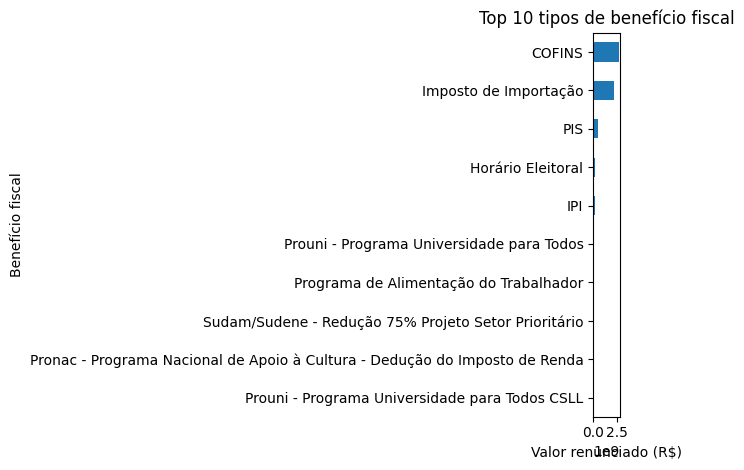

In [15]:

ax = top_beneficios.head(10).sort_values('valor_renunciado').plot(
    kind='barh', x='Benefício Fiscal', y='valor_renunciado', legend=False
)
ax.set_title('Top 10 tipos de benefício fiscal')
ax.set_xlabel('Valor renunciado (R$)')
ax.set_ylabel('Benefício fiscal')
plt.tight_layout()
plt.show()


### Leitura dos benef?cios

COFINS, Imposto de Importa??o, PIS e IPI concentram a maior parte dos valores observados. Essa composi??o refor?a que a base est? ancorada, sobretudo, em tributos federais incidentes sobre empresas instaladas em Santos.


## 7. Relação entre setor e tipo de benefício

In [16]:

matriz = pd.pivot_table(
    santos,
    values='valor_renunciado',
    index='CNAE',
    columns='Benefício Fiscal',
    aggfunc='sum',
    fill_value=0
)

# Mantém apenas os setores mais relevantes para facilitar leitura
matriz_top = matriz.loc[top_cnae.head(10)['CNAE']]
matriz_top


Benefício Fiscal,Atividade Audiovisual - Dedução do Imposto de Renda,COFINS,Empresa Cidadã,Fundos de Direitos da Criança e do Adolescente,Fundos do Idoso,Horário Eleitoral,IPI,Imposto de Importação,Incentivo ao Desporto,PIS,Programa Emergencial de Retomada do Setor de Eventos (Perse) - CSLL,Programa Emergencial de Retomada do Setor de Eventos (Perse) - IRPJ,Programa de Alimentação do Trabalhador,Pronac - Programa Nacional de Apoio à Cultura - Dedução do Imposto de Renda,Pronas/PCD - Programa Nacional de Apoio à Atenção da Saúde da Pessoa com Deficiência,Pronon - Programa Nacional de Apoio à Atenção Oncológica,Prouni - Programa Universidade para Todos,Prouni - Programa Universidade para Todos CSLL,Sudam/Sudene - Redução 75% Projeto Setor Prioritário
CNAE,,,,,,,,,,,,,,,,,,,
09106 - Atividades de apoio à extração de petróleo e gás natural,0.0,796848849.0,0.00,0.00,0.0,0.000000e+00,6126079.0,1.046601e+09,0.00,157124936.0,0.00,0.00,23795.26,0.00,0.0,0.0,0.0,0.0,0.00
06000 - Extração de petróleo e gás natural,0.0,498363368.0,0.00,0.00,0.0,0.000000e+00,83687395.0,6.663450e+08,0.00,102904465.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00
10627 - Moagem de trigo e fabricação de derivados,0.0,607332745.0,0.00,0.00,0.0,0.000000e+00,0.0,6.719065e+06,0.00,132159426.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00
52117 - Armazenamento,0.0,228553893.0,173690.01,0.00,20000.0,0.000000e+00,31345758.0,5.455081e+07,0.00,49671893.0,0.00,0.00,3935560.84,2045000.00,0.0,0.0,0.0,0.0,38639557.73
00000 - Sem informação,0.0,147152472.0,0.00,21652.04,0.0,0.000000e+00,1222438.0,1.708382e+08,0.00,32009261.0,9383.79,15639.66,1403570.67,0.00,0.0,0.0,0.0,0.0,0.00
"46842 - Comércio atacadista de produtos químicos e petroquímicos, exceto agroquímicos",0.0,76174696.0,0.00,0.00,0.0,0.000000e+00,7805933.0,1.230906e+08,0.00,16576017.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00
60217 - Atividades de televisão aberta,0.0,241681.0,0.00,0.00,0.0,1.587740e+08,0.0,0.000000e+00,0.00,50822.0,0.00,0.00,58260.12,0.00,0.0,0.0,0.0,0.0,0.00
52311 - Gestão de portos e terminais,900000.0,49368565.0,2256758.55,3761838.14,780597.3,0.000000e+00,2206356.0,4.940871e+07,4058404.42,10016675.0,0.00,0.00,20539563.74,13558974.47,212360.0,325360.0,0.0,0.0,0.00
46397 - Comércio atacadista de produtos alimentícios em geral,0.0,69174233.0,0.00,0.00,0.0,0.000000e+00,0.0,2.600000e+01,0.00,15044493.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00


In [ ]:

plt.figure(figsize=(14, 7))
plt.imshow(matriz_top, aspect='auto')
plt.colorbar(label='Valor renunciado (R$)')
plt.xticks(range(len(matriz_top.columns)), matriz_top.columns, rotation=90)
plt.yticks(range(len(matriz_top.index)), matriz_top.index)
plt.title('Setor econômico × tipo de benefício fiscal')
plt.tight_layout()
plt.show()


### Padr?es a observar

- Petr?leo e g?s tende a concentrar Imposto de Importa??o, COFINS e PIS.
- Alimentos e moagem costumam aparecer com peso maior em COFINS e PIS.
- Televis?o aberta chama aten??o por um benef?cio muito espec?fico, ligado ao hor?rio eleitoral.
- Portos, terminais e armazenagem se conectam mais claramente ? l?gica de log?stica e com?rcio exterior.


## 8. Cenário hipotético sem renúncias

In [17]:

print(f'Valor total de renúncia incidente sobre empresas localizadas em Santos: R$ {total:,.2f}')


Valor total de renúncia incidente sobre empresas localizadas em Santos: R$ 5,897,833,221.41


### O que este exerc?cio permite dizer

Se as ren?ncias listadas n?o existissem, o valor potencial incidente sobre as empresas do recorte seria equivalente ao total estimado na base.

### O que ele n?o permite dizer

Esse resultado n?o pode ser convertido automaticamente em ?perda da Prefeitura de Santos?, porque os tributos dominantes n?o pertencem, em sua maior parte, ? esfera municipal.

A formula??o mais segura ?: empresas sediadas em Santos concentraram aproximadamente esse montante em ren?ncias fiscais, sobretudo em tributos federais.


## 9. Limitações da base

Principais limites desta base:

1. ela n?o mede arrecada??o municipal efetiva;
2. n?o informa empregos por empresa;
3. n?o mostra contrapartidas dos programas;
4. n?o permite medir retorno social ou fiscal do incentivo;
5. h? registros com descri??o setorial incompleta.


## 10. Conclusões

### Fechamento

1. As ren?ncias fiscais incidentes sobre empresas sediadas em Santos alcan?am um volume bilion?rio.
2. A distribui??o ? bastante concentrada em poucos registros.
3. Petr?leo, log?stica, armazenagem, portos e alimentos aparecem com destaque.
4. Os benef?cios mais pesados est?o ligados principalmente ? esfera federal.
5. A base n?o autoriza, sozinha, a conclus?o de perda direta da Prefeitura de Santos nesse mesmo montante.


## 11. Próximas análises recomendadas

Para avan?ar, o passo mais ?til ? cruzar esta base com emprego formal, arrecada??o municipal e indicadores setoriais. Sozinha, a planilha descreve concentra??o e perfil econ?mico, mas n?o resolve a discuss?o sobre retorno do incentivo.

Perguntas que fazem sentido na pr?xima etapa:

- As empresas que mais recebem benef?cios tamb?m s?o as que mais empregam?
- Os setores mais beneficiados tamb?m est?o entre os que mais geram receita local?
- A concentra??o observada acompanha ganhos mensur?veis para a economia do munic?pio?
